In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

import os
import torch
import argparse
import yaml
from numba import cuda

from helpers.density_estimator import DensityEstimator
from helpers.ANODE_training_utils import train_ANODE, plot_ANODE_losses
from helpers.data_transforms import preprocess_data, inverse_preprocess_data
from sklearn.preprocessing import StandardScaler, MinMaxScaler


from helpers.flow_sampling import get_flow_samples


/global/homes/r/rmastand/.local/lib/python3.8/site-packages/zfit/__init__.py:63: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


In [2]:

SEED = 8
BATCH_SIZE = 1024
NUM_FEATURES = 5
EPOCHS = 50
PATIENCE = 5
CONFIG = "CATHODE_8"

In [3]:

# computing
device = cuda.get_current_device()
device.reset()
torch.set_num_threads(2)
device = torch.device( "cuda" if torch.cuda.is_available() else "cpu")
print( "Using device: " + str( device ), flush=True)
seed = int(SEED)
torch.manual_seed(seed)
np.random.seed(seed)

Using device: cuda


In [10]:



path_to_config_file = f"configs/{CONFIG}.yml"
flow_training_dir = f"/pscratch/sd/r/rmastand/muon/models/{CONFIG}"
os.makedirs(flow_training_dir, exist_ok=True)



In [5]:
collections_TrackerHitPlane = [
    "IBTrackerHits",
    "IBTrackerHitsConed",
    "IETrackerHits", 
    "IETrackerHitsConed",
    "OBTrackerHits",
    "OBTrackerHitsConed", 
    "OETrackerHits",        
    "OETrackerHitsConed",          
    "VBTrackerHits",               
    "VBTrackerHitsConed",   
    "VETrackerHits",  
    "VETrackerHitsConed",        
]

collections_SimTrackerHit = [
  #  "InnerTrackerBarrelCollection",
   # "InnerTrackerBarrelCollectionConed",
  #  "InnerTrackerEndcapCollection",
    #"InnerTrackerEndcapCollectionConed", 
    "OuterTrackerBarrelCollection",     
  #  "OuterTrackerBarrelCollectionConed",
  #  "OuterTrackerEndcapCollection",  
   # "OuterTrackerEndcapCollectionConed",
 #   "VertexBarrelCollection",   
  #  "VertexBarrelCollectionConed",   
  #  "VertexEndcapCollection",
   # "VertexEndcapCollectionConed",
]


feature_labels = ["$E$", "$x$", "$y$", "$z$", "$t$", "noise"]

In [26]:

data = []

for collection in collections_SimTrackerHit: # TODO coned too?
    
    tmp = np.load(f"/pscratch/sd/r/rmastand/muon/npys/{collection}_SimTrackerHit.npy")
    data.append(tmp)

data = np.vstack(data)


bins_dict = {}

for i in range(5):
    if i in [0, 4]:
        bins_dict[i] = np.logspace(np.log10(np.min(data[:,i])), np.log10(np.max(data[:,i])), 100) 
    else:
        bins_dict[i] = np.linspace(np.min(data[:,i]), np.max(data[:,i]), 100) 
bins_dict[5] = np.linspace(-5, 5, 100)

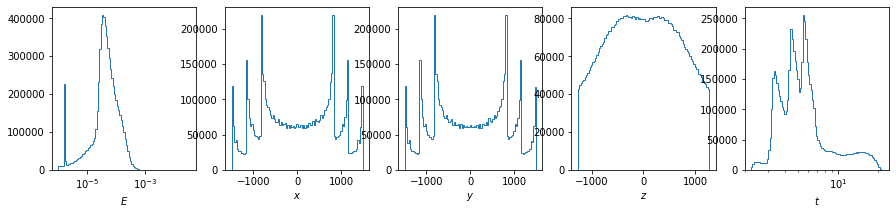

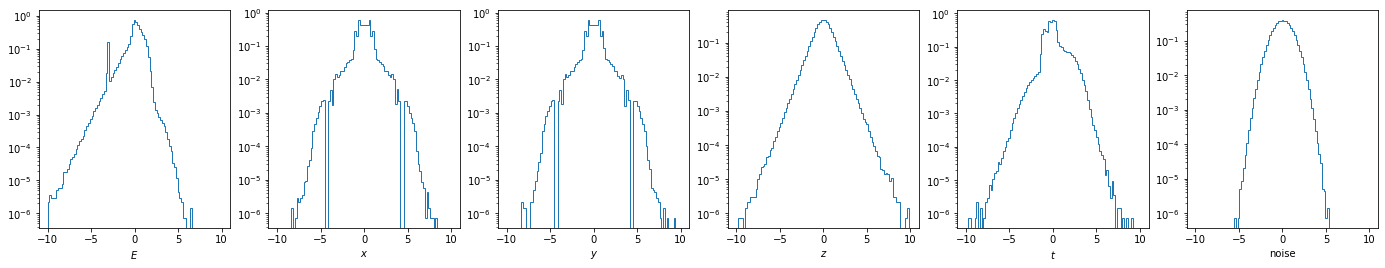

In [29]:
X_preproc = preprocess_data(data)

fig, ax = plt.subplots(1, 5, figsize = (15, 3))
for i in range(5):
    ax[i].hist(data[:,i], bins = bins_dict[i], histtype = "step", label = "data")
    ax[i].set_xlabel(feature_labels[i])
    if i in [0, 4]:
        ax[i].set_xscale("log")
plt.show()

    

# add a random noise feature for now
X_preproc = np.hstack([X_preproc,  np.random.normal(size=(len(X_preproc),1))])


fig, ax = plt.subplots(1, 6, figsize = (24, 4))
for i in range(6):
    ax[i].hist(X_preproc[:,i], bins = np.linspace(-10, 10, 100), histtype = "step", density = True)
    ax[i].set_xlabel(feature_labels[i])
    ax[i].set_yscale("log")
plt.show()

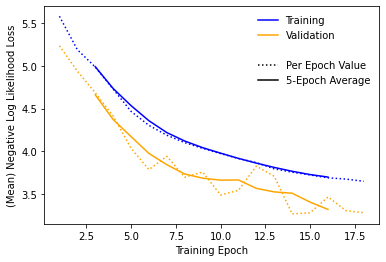

In [20]:


# plot losses
train_losses = np.load(os.path.join(flow_training_dir, f"flow_train_losses.npy"))
val_losses = np.load(os.path.join(flow_training_dir, f"flow_val_losses.npy"))
val_losses = val_losses[train_losses < 1e20]
train_losses = train_losses[train_losses < 1e20]
plot_ANODE_losses(train_losses, val_losses, yrange=None,
savefig=os.path.join(flow_training_dir, f"loss_plot"),suppress_show=False)



In [21]:

"""
MAKE SAMPLES
"""
print()
print("Making flow samples...")

# get epoch of best val loss
best_epoch = np.nanargmin(val_losses) - 1
model_path = f"{flow_training_dir}/flow_epoch_{best_epoch}.par"

eval_model = DensityEstimator(path_to_config_file, NUM_FEATURES,
                         eval_mode=True,
                         load_path=model_path,
                         device=device, verbose=False,
                         bound=False)









Making flow samples...
DensityEstimator has 42144 parameters
Loading model parameters from /pscratch/sd/r/rmastand/muon/models/CATHODE_8/flow_epoch_13.par


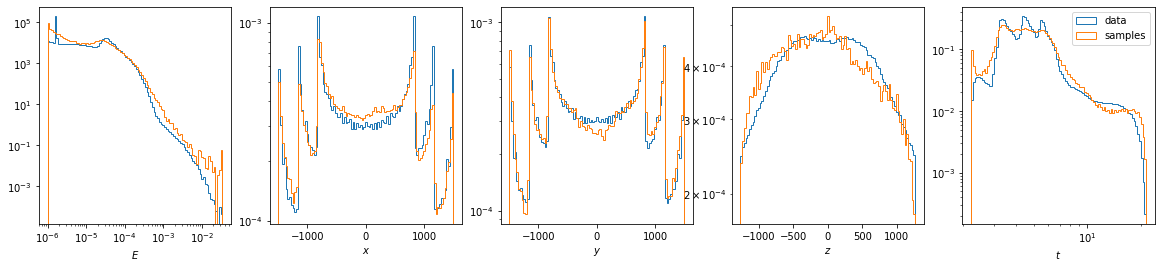

In [30]:

X_sample = get_flow_samples(eval_model, np.random.normal(size=(100000,))) 
X_sample = inverse_preprocess_data(X_sample[:,:-1])



fig, ax = plt.subplots(1, 5, figsize = (20, 4))
for i in range(5):
    ax[i].hist(data[:,i], bins = bins_dict[i], histtype = "step", density = True, label = "data")
    ax[i].hist(X_sample[:,i], bins = bins_dict[i], histtype = "step", density = True, label = "samples")
    ax[i].set_yscale("log")
    ax[i].set_xlabel(feature_labels[i])
    if i in [0, 4]:
        ax[i].set_xscale("log")
ax[-1].legend()
plt.show()



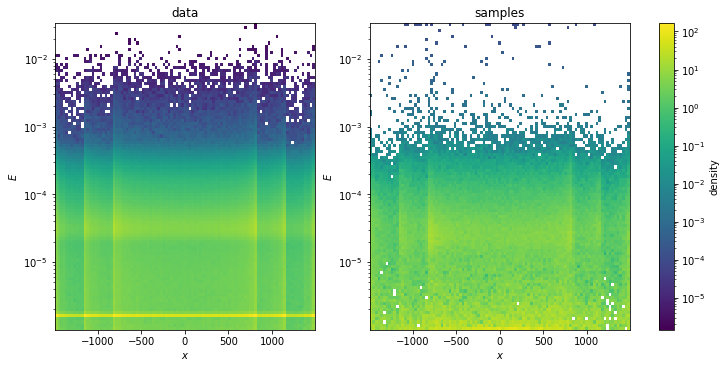

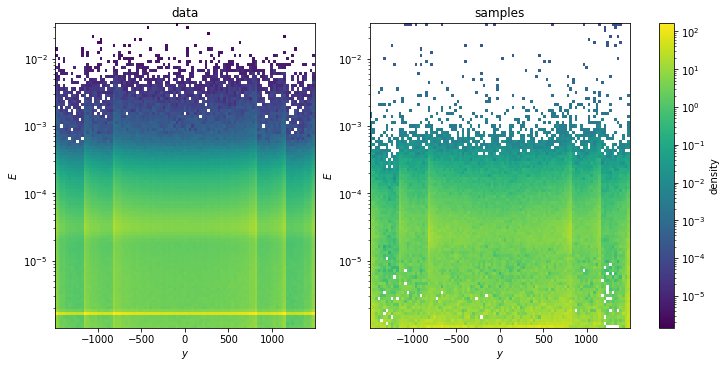

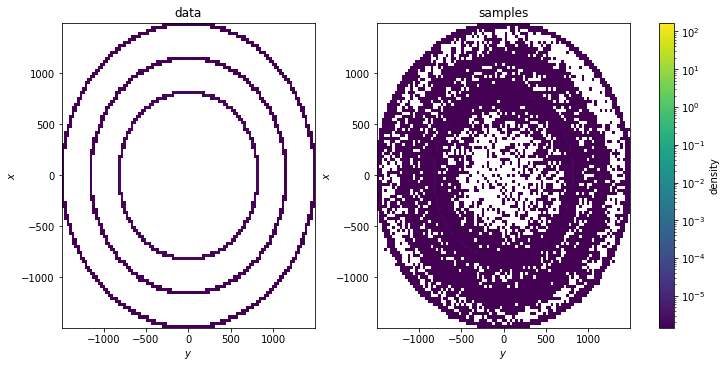

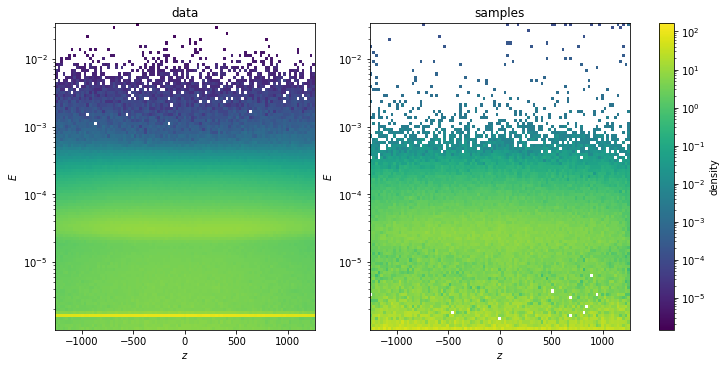

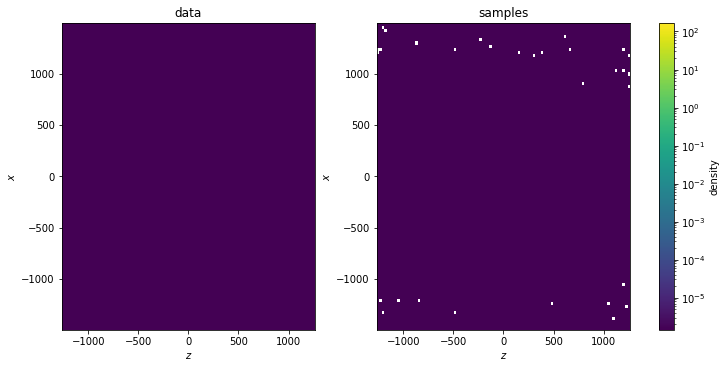

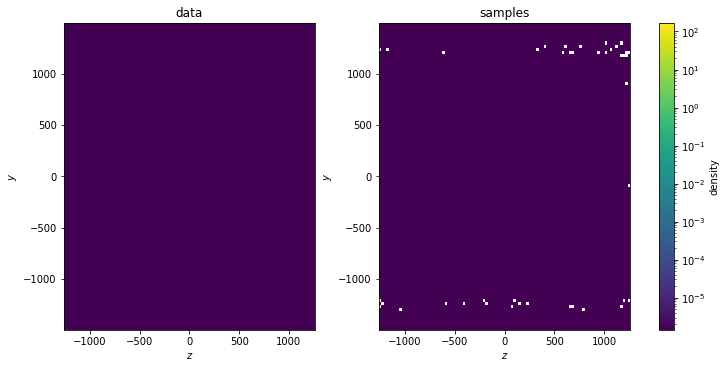

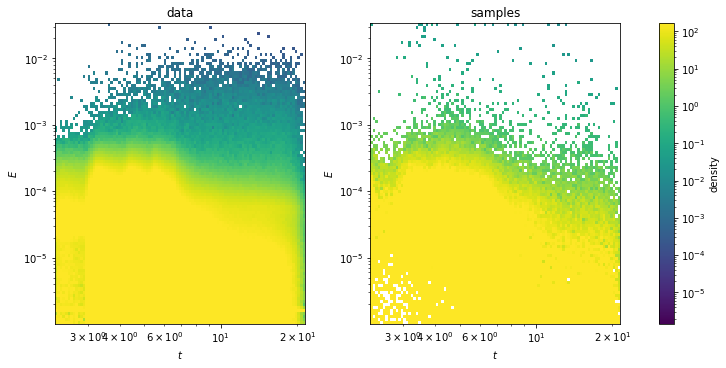

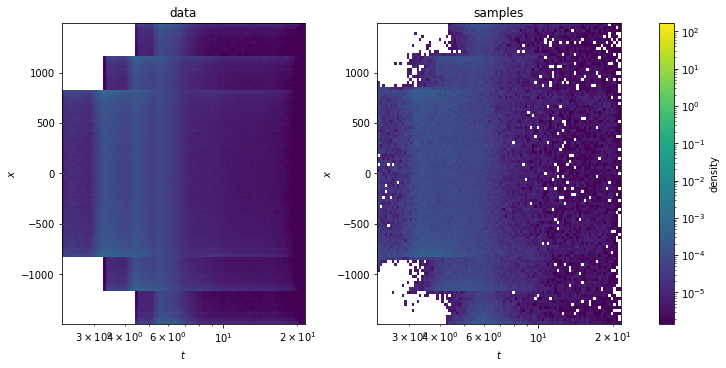

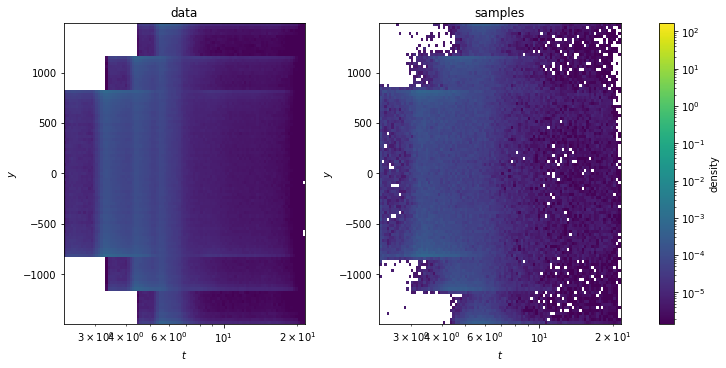

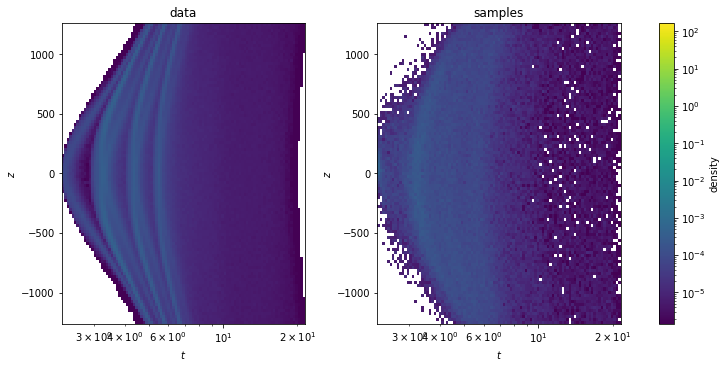

In [31]:

from matplotlib.colors import LogNorm

norm = LogNorm()

for i in range(5):
    for j in range(i):
        fig, ax = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

        h0 = ax[0].hist2d(
            data[:, i], data[:, j],
            bins=[bins_dict[i], bins_dict[j]],
            norm=norm,
            density=True
        )
        ax[0].set_xlabel(feature_labels[i])
        ax[0].set_ylabel(feature_labels[j])
        if i in [0, 4]:
            ax[0].set_xscale("log")
        if j in [0, 4]:
            ax[0].set_yscale("log")
        ax[0].set_title("data")

        h1 = ax[1].hist2d(
            X_sample[:, i], X_sample[:, j],
            bins=[bins_dict[i], bins_dict[j]],
            norm=norm,
            density=True
        )
        ax[1].set_xlabel(feature_labels[i])
        ax[1].set_ylabel(feature_labels[j])
        if i in [0, 4]:
            ax[1].set_xscale("log")
        if j in [0, 4]:
            ax[1].set_yscale("log")
        ax[1].set_title("samples")

        # shared colorbar
        cbar = fig.colorbar(h0[3], ax=ax, label="density")

        plt.show()
